Logistic Regression

In [44]:
import numpy as np

# Sigmoid function
def sigmoid(z):
    return 1/(1 +  np.exp(-z))

# Loss function
def computer_loss(y_true, y_pred):
    m = y_true.shape[0]
    y_pred = np.clip(y_pred, 1e-10, 1 - 1e-10)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# Logistic Regression
class LogisticRegressionScratch:
    # lr: learning rate, epoches: number of interactions
    def __init__(self, lr=0.01, epochs = 1000):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = None

    def fit(self, X, y):
        m, n = X.shape
        self.w = np.zeros(n)
        self.b = 0

        for i in range(self.epochs):
            z = np.dot(X, self.w) + self.b
            y_pred = sigmoid(z)

            # Gradient
            dw = (1/m) * np.dot(X.T, (y_pred - y))
            db = (1/m) * np.sum(y_pred - y)

            # Update Weight
            self.w -= self.lr * dw
            self.b -= self.lr * db

    def predict_prob(self, X):
            z = np.dot(X, self.w) + self.b
            return sigmoid(z)
        
    def predict(self, X):
            return (self.predict_prob(X) >= 0.5).astype(int)


IMPORT LIBRARY

In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import string                                                   # Processing strings related to the alphabet and special characters.
import re                                                       # Process the string using Regular Expressions to clean and extract data.

from sklearn.model_selection import train_test_split            # Split data train/test
from sklearn.feature_extraction.text import TfidfVectorizer     # Change text to number (TF-IDF)
from sklearn.metrics import (
    accuracy_score,         
    classification_report,  # Report precision, recall, f1-score
    confusion_matrix,       # Confusion matrix
    ConfusionMatrixDisplay  # Visualization confusion matrix
)



Load data

In [46]:
df = pd.read_csv('email.csv')
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [47]:
df.shape # show the number of rows and columns

(5572, 2)

In [48]:
df.info() # show the number of columns, column labels, data types, memory usage, and the number of non-null values in each column.

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Category  5572 non-null   str  
 1   Message   5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [49]:
df.columns.tolist() # Transform dataframe to python list

['Category', 'Message']

In [50]:
df.isnull().sum() #It checks for missing values ​​in each column and returns the total number of empty values ​​in each column, helping to identify any spaces in your data.

Category    0
Message     0
dtype: int64

In [51]:
df.nunique() #It counts the number of unique different values ​​in each column, eliminating duplicate value loops.

Category       2
Message     5157
dtype: int64

EDA

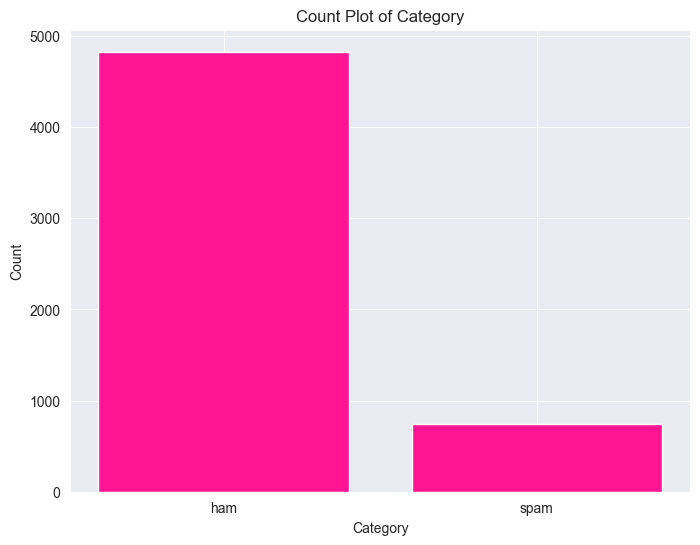

In [52]:
# Use a bar plot to find out the distribution of the data.
quality_counts = df['Category'].value_counts()

plt.figure(figsize=(8,6))
plt.bar(quality_counts.index, quality_counts, color='deeppink')
plt.title('Count Plot of Category') # Distribution of data
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

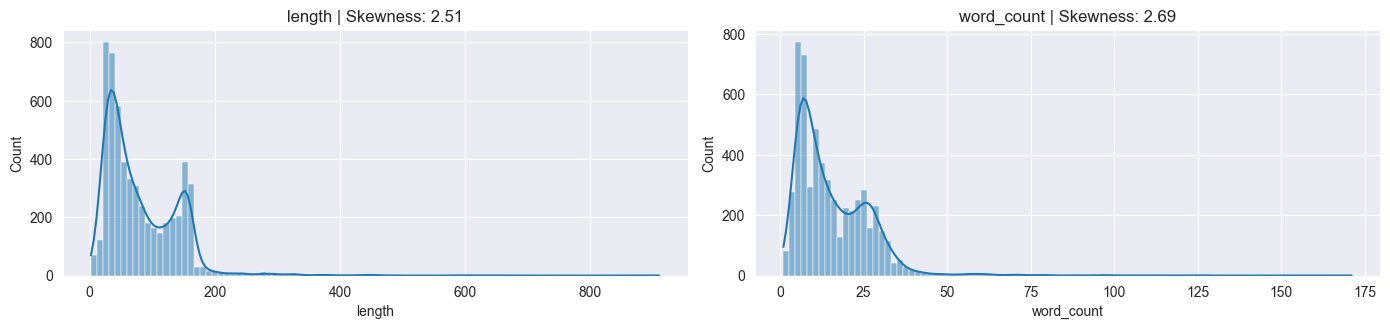

In [53]:
# Use a kernel density plot to understand the distribution and skewness in a column of data.
sns.set_style("darkgrid")

# Create a numeric feature from text.
df['length'] = df['Message'].apply(len) # length of message
df['word_count'] = df['Message'].apply(lambda x: len(x.split())) # number of words


numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 2, idx)
    sns.histplot(df[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(df[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_5288\1881283533.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Category', y='num_punctuation', data=df.sample(1000, random_state=42), palette='viridis', size=3)
d:\Codepython\Practice\venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 10.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
d:\Codepython\Practice\venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 32.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


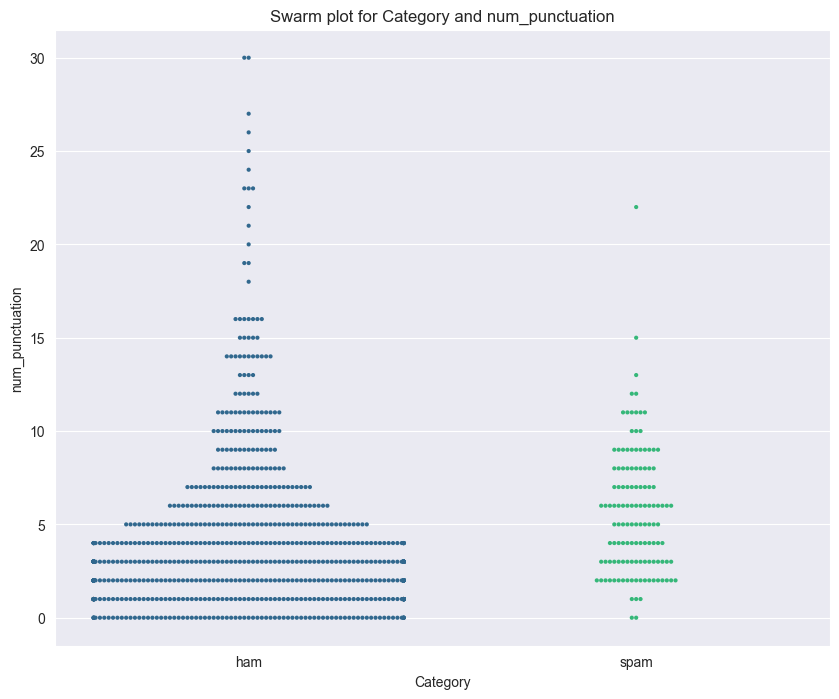

In [54]:
# Use a swarm plot to check the relationship between category and punctuation.
df['num_punctuation'] = df['Message'].apply(lambda x: len([char for char in x if char in string.punctuation]))

plt.figure(figsize=(10, 8))

sns.swarmplot(x='Category', y='num_punctuation', data=df.sample(1000, random_state=42), palette='viridis', size=3)

plt.title('Swarm plot for Category and num_punctuation')
plt.xlabel('Category')
plt.ylabel('num_punctuation')
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_5288\3222787425.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Category', y='num_caps', data=df, palette={'ham': 'lightskyblue', 'spam': 'lightcoral'}, alpha=0.7)


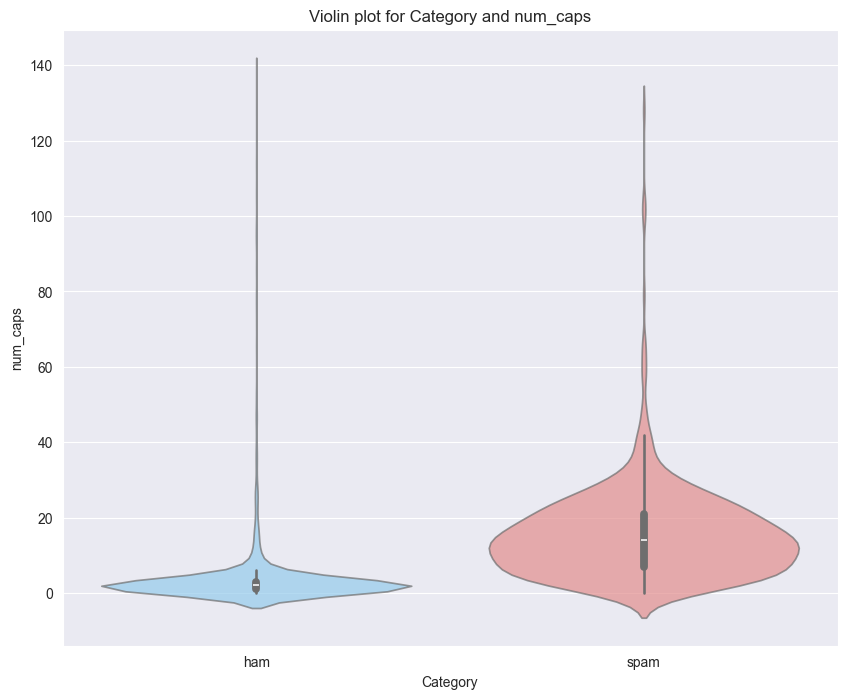

In [55]:
# Use a violin plot to check the relationship between category and Capital letters.
df['Category'] = df['Category'].astype(str)
df['num_caps'] = df['Message'].apply(lambda x: sum(1 for char in x if char.isupper()))

plt.figure(figsize=(10, 8))

sns.violinplot(x='Category', y='num_caps', data=df, palette={'ham': 'lightskyblue', 'spam': 'lightcoral'}, alpha=0.7)

plt.title('Violin plot for Category and num_caps')
plt.xlabel('Category')
plt.ylabel('num_caps')
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_5288\289388044.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='total_hot_words', data=df, palette={'ham': 'skyblue', 'spam': 'salmon'})


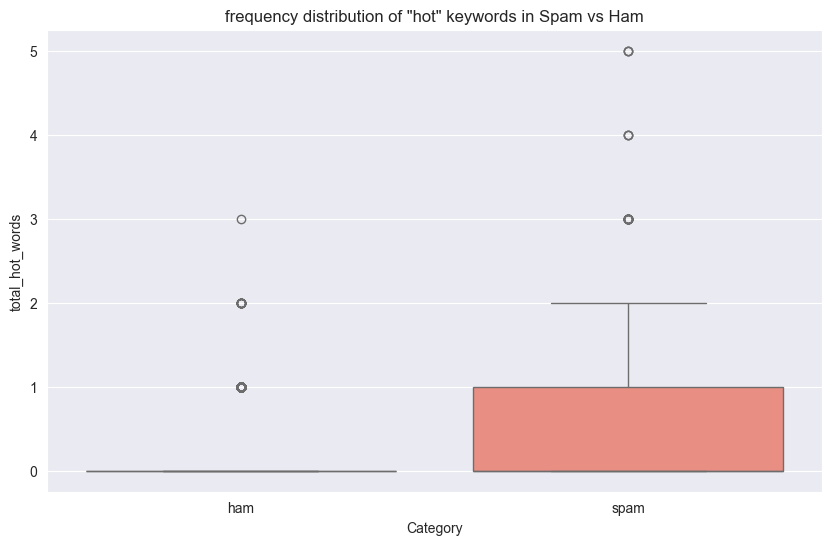

In [56]:
# Use box plot to frequency distribution of "hot" keywords in Spam vs Ham.
# Defind list of hot words
hot_words = ['free', 'win', 'click', 'money', 'prize', 'urgent', 'winner']

# Create a column to count the total number of times these words appear in the Message.
df['total_hot_words'] = df['Message'].apply(lambda x: sum(x.lower().count(word) for word in hot_words))

# Draw box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Category', y='total_hot_words', data=df, palette={'ham': 'skyblue', 'spam': 'salmon'})
plt.title('frequency distribution of "hot" keywords in Spam vs Ham')
plt.show()

In [57]:
df.describe() .T #This method provides a summary table of the DataFrame (Transpose) displaying values ​​such as count, mean, standard deviation, minimum, and quartile for each column.

,count,mean,std,min,25%,50%,75%,max
length,5572.0,80.368988,59.926946,2.0,35.75,61.0,122.0,910.0
word_count,5572.0,15.584171,11.406598,1.0,7.00,12.0,23.0,171.0
num_punctuation,5572.0,4.174444,4.622812,0.0,2.00,3.0,6.0,133.0
num_caps,5572.0,5.628859,11.708437,0.0,1.00,2.0,4.0,138.0
total_hot_words,5572.0,0.139088,0.467813,0.0,0.00,0.0,0.0,5.0


PREPROCESSING DATA

- Clean and normalize data

In [58]:
# Preprocessing data
df = df.drop_duplicates()

def clean_text(text):
    text = text.lower()                                 # change from "Free Money" to "free money"
    text = re.sub(f"[{string.punctuation}]", "", text)  # Remove punctuation: "Hello^^* Free?? Money." to "Hello Free Money"
    text = re.sub(r"\d+", "", text)                     # Remove number from "win 1000 dollars now" to "win dollars now"
    return text

df['Message'] = df['Message'].apply(clean_text)

- Label encryption

In [59]:
df = df[df["Category"].isin(['ham', 'spam'])] # only collect spam and ham samples.

X = df["Message"]
y = df["Category"]

print("Check label distribution: ")
print(y.value_counts())

print("\nCheck the label distribution by percentages: ")
print(y.value_counts()/len(y))

y = y.map({
    'ham': 0,
    'spam': 1
}) # Change label to number

Check label distribution: 
Category
ham     4516
spam     641
Name: count, dtype: int64

Check the label distribution by percentages: 
Category
ham     0.875703
spam    0.124297
Name: count, dtype: float64


Data processing

- Split the training/test set

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    stratify = y,
    random_state = 42
)

print("The training/testing time has been split at an 80/20 ratio.")

The training/testing time has been split at an 80/20 ratio.


- TF-IDF Vectorizer

In [61]:
# Convert text to digital vectors
vectorizer = TfidfVectorizer()

# Train vectorizer with training data.
vectorizer.fit(X_train)

# Convert training data into digital vectors.
X_train_tfidf = vectorizer.transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)


TRAINING MODEL

In [42]:
# Use logistic Regression
model = LogisticRegressionScratch(lr=0.01, epochs=1000)
model.fit(X_train_tfidf.toarray(), y_train)

print("The model has been trained.")

The model has been trained.


EVALUATION MODEL

Logistic Regression (train 80% / test 20%)
Accuracy:  0.875968992248062

Confusion Matrix: 


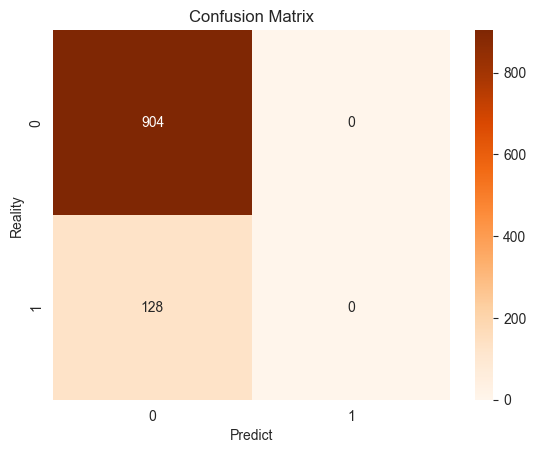


Classification Report: 
              precision    recall  f1-score   support

           0       0.88      1.00      0.93       904
           1       0.00      0.00      0.00       128

    accuracy                           0.88      1032
   macro avg       0.44      0.50      0.47      1032
weighted avg       0.77      0.88      0.82      1032



d:\Codepython\Practice\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Codepython\Practice\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Codepython\Practice\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [43]:
# Predict labels on the test set.
y_pred = model.predict(X_test_tfidf.toarray())

# calculate accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Logistic Regression (train 80% / test 20%)")
print("Accuracy: ", acc)

# Draw confusion matrix
print("\nConfusion Matrix: ")
cm = confusion_matrix(y_test, y_pred)
plt.Figure(figsize=(4,4))
sns.heatmap(
    cm,             
    annot = True,   # Print the value in each cell.
    fmt = "d",      # integer format
    cmap = "Oranges"  # orange
)
plt.title("Confusion Matrix")
plt.xlabel("Predict")
plt.ylabel("Reality")
plt.show()

# Report of key metrics: precision, recall, F1-score
print("\nClassification Report: ")
print(classification_report(y_test, y_pred))